## Self-TICA: Learning slow modes via self-supervised learning.

## Introduction
### Contrastive loss

The transfer operator $\mathcal{T}_{\tau}$ governs the time evolution of a system and can be written as

$$
(\mathcal{T}_{\tau} f)(\mathbf{R}_t)
=
\mathbb{E}\!\left[ f(\mathbf{R}_{t+\tau}) \mid \mathbf{R}_t \right]
=
\mathbb{E}\!\left[
r(\mathbf{R}_t,\mathbf{R}_{t+\tau})\, f(\mathbf{R}_{t+\tau})
\right],
$$

where the density ratio
$$
r(\mathbf{R}_t,\mathbf{R}_{t+\tau})
=
\frac{p(\mathbf{R}_{t+\tau} \mid \mathbf{R}_t)}{p(\mathbf{R}_{t+\tau})}
$$
encodes the temporal dependence between configurations, assigning higher weights to dynamically consistent pairs.

To approximate this quantity, we introduce a learned representation $z_t=\varphi(\mathbf{R}_t)$ and model the density ratio as a bilinear form
$
r(\mathbf{R}_t,\mathbf{R}_{t+\tau})
\approx
\langle P z_t,\, z_{t+\tau} \rangle,
$
where $P$ captures time-lagged correlations.

Since the true density ratio is unknown, we instead define a contrastive objective based on the score
$
D_{ij} = \langle P z_t^{(i)}, z_{t+\tau}^{(j)} \rangle,
$
which enforces high similarity for matched pairs ($i=j$) and low similarity otherwise:
$$
\hat{\mathcal{L}}(\varphi, P)
=
\frac{1}{N(N-1)} \sum_{i \neq j} D_{ij}^2
-
\frac{2}{N} \sum_{i=1}^N D_{ii}.
$$

### Connection to the VAMP-2 score

When $P$ attains its optimal form

$$
P^* = C_\tau C_0^{-1},
$$

it corresponds to the best linear predictor mapping current features to their time-lagged counterparts.

Substituting $P^*$ into the loss yields

$$
\mathcal{L}(\varphi, P^*)
=
-\operatorname{Tr}\!\left(
C_0^{-1} C_\tau C_\tau^\top
\right)
=
-\mathrm{VAMP}_2(\varphi),
$$

showing that minimizing the self-supervised objective is equivalent to maximizing the VAMP-2 score.

### Nonlinear predictor for biased dynamics

Under a bias potential $V$, the corresponding transfer operator is no longer a simple linear modification of $\mathcal{T}_\tau$, due to the non-commutativity of the underlying operators.

As a result, the mapping from $\varphi(\mathbf{R}_t)$ to $\varphi(\mathbf{R}_{t+\tau})$ becomes effectively nonlinear. A linear predictor may therefore be insufficient, motivating the use of nonlinear models to better capture the resulting dynamics.

### Extract CVs from TICA
After training the encoder $\varphi$ (either a feed-forward neural network or a graph neural network), we can apply **Time-Lagged Independent Component Analysis (TICA)** to the learned evolution operators to extract the CVs. TICA identifies the dominant slow modes by maximizing the time-lagged autocorrelation of the encoded features, yielding CVs that best characterize the system’s slow conformational transitions. This procedure is conceptually analogous to Deep-TICA, where neural representations are refined to capture long-timescale dynamics in a non-linear latent space.

## Setup

In [1]:
# Colab setup
import os

if os.getenv("COLAB_RELEASE_TAG"):
    import subprocess
    subprocess.run('wget https://raw.githubusercontent.com/luigibonati/mlcolvar/main/colab_setup.sh', shell=True)
    cmd = subprocess.run('bash colab_setup.sh TUTORIAL', shell=True, stdout=subprocess.PIPE)
    print(cmd.stdout.decode('utf-8'))

# IMPORT PACKAGES
import torch
import lightning
import numpy as np
import matplotlib.pyplot as plt

# IMPORT HELPER FUNCTIONS
from mlcolvar.utils.plot import muller_brown_potential, plot_isolines_2D

# Set seed for reproducibility
torch.manual_seed(42)
torch.set_default_dtype(torch.float64)

/home/kzhu-iit.local/miniconda3/envs/mlcolvar-gnn/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load data

In [2]:
from mlcolvar.utils.io import load_dataframe
from mlcolvar.utils.timelagged import create_timelagged_dataset
from mlcolvar.data import DictModule

filenames = [ "data/muller-brown/biased/opes-x/COLVAR"]

# load file
df = load_dataframe(filenames, start=0, stop=10000, stride=5)

# get descriptors
X = df.filter(regex='p.x|p.y').values

# build time-lagged dataset (composed by pairs of configs at time t, t+lag)
dataset = create_timelagged_dataset(X, lag_time=1)

# create datamodule 
datamodule = DictModule(dataset, lengths=[0.8, 0.2])

### Define model
Here are a few tips and tricks about the hyperparameters:
- The self-supervised loss $\varepsilon(\phi, P^*)$ converges to the negative VAMP-2 score only when the predictor $P$ reaches its optimal form $P^*$. Therefore, do not be confused if the eigenvalues decrease during the initial stages of training, this is a normal behavior.
- The algorithm requires sufficient model expressiveness so that the predictor $P$ can approximate its optimal form.  If the predictor is too weak, the eigenvalues may collapse toward zero. It is recommended to use an encoder with at least three layers to ensure stable learning.
- Beware of overfitting. It is recommended to stop training once the eigenvalues have stabilized or converged, as continuing beyond this point may cause the learned CVs to become overly sharp or narrowly shaped.

In [ ]:
from mlcolvar.cvs import SelfTICA

n_components = 1
encoder_layers = [2, 15, 15, 5]
options= {'nn': {'activation': 'shifted_softplus'}}

model = SelfTICA(encoder_layers, predictor_depth=3, n_cvs=n_components, options=options)

model

SelfTICA(
  (loss_fn): ContrastiveLoss()
  (norm_in): Normalization(in_features=2, out_features=2, mode=mean_std)
  (nn): FeedForward(
    (nn): Sequential(
      (0): Linear(in_features=2, out_features=15, bias=True)
      (1): Shifted_Softplus(beta=1, threshold=20)
      (2): Linear(in_features=15, out_features=15, bias=True)
      (3): Shifted_Softplus(beta=1, threshold=20)
      (4): Linear(in_features=15, out_features=5, bias=True)
    )
  )
  (predictor): FeedForward(
    (nn): Sequential(
      (0): Linear(in_features=5, out_features=5, bias=True)
      (1): ReLU(inplace=True)
      (2): Linear(in_features=5, out_features=5, bias=True)
    )
  )
  (tica): TICA(in_features=5, out_features=1)
)

### Define Trainer & Fit

In [4]:
from mlcolvar.utils.trainer import MetricsCallback

# define callbacks
metrics = MetricsCallback()

# define trainer
trainer = lightning.Trainer(callbacks=[metrics],
                     max_epochs=400, logger=None, enable_checkpointing=False)

# fit
trainer.fit( model, datamodule )

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
/home/kzhu-iit.local/miniconda3/envs/mlcolvar-gnn/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type            | Params | Mode  | FLOPs | In sizes | Out sizes
----

/home/kzhu-iit.local/miniconda3/envs/mlcolvar-gnn/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:317: The number of training batches (1) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Epoch 399: 100%|██████████| 1/1 [00:00<00:00, 38.81it/s, v_num=20] 

`Trainer.fit` stopped: `max_epochs=400` reached.


Epoch 399: 100%|██████████| 1/1 [00:00<00:00, 37.09it/s, v_num=20]


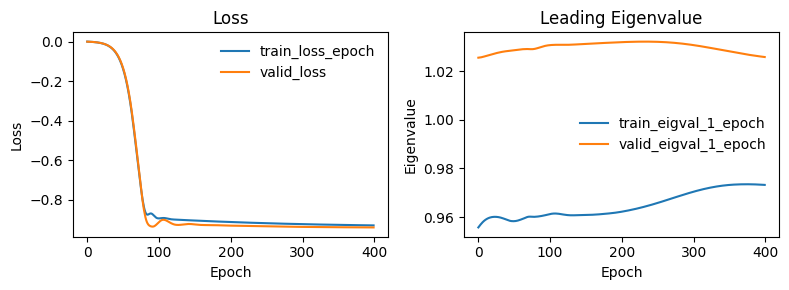

In [5]:
from mlcolvar.utils.plot import plot_metrics

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3), sharex=True)

plot_metrics(
    metrics.metrics,
    keys=['train_loss_epoch', 'valid_loss'],
    ax=ax1,
    yscale='linear'
)
ax1.set_ylabel('Loss')
ax1.set_title('Loss')

plot_metrics(
    metrics.metrics,
    keys=['train_eigval_1_epoch', 'valid_eigval_1_epoch'],
    ax=ax2,
    yscale='linear'
)
ax2.set_ylabel('Eigenvalue')
ax2.set_title('Leading Eigenvalue')

plt.xlabel('Epoch')
plt.tight_layout()
plt.show()

### Plot encoder features

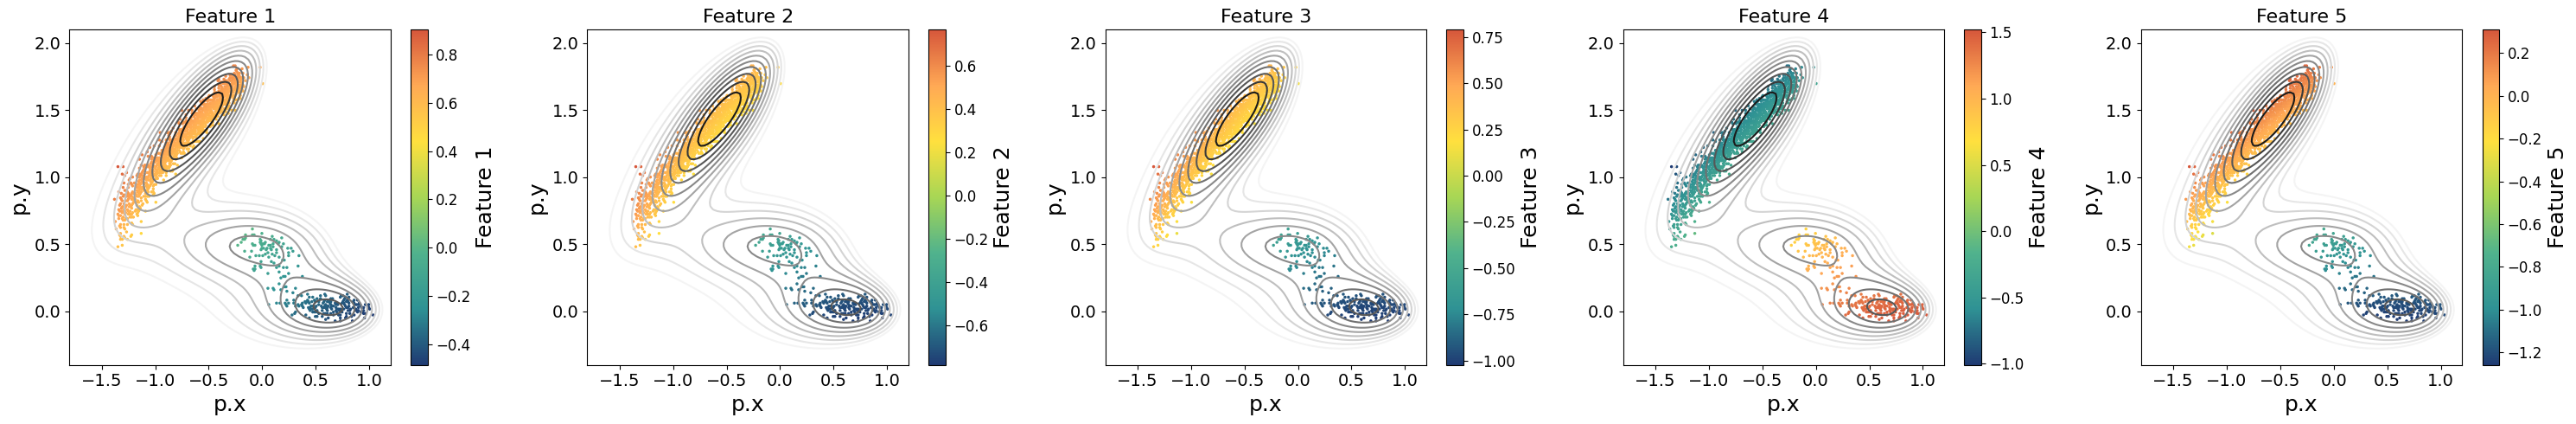

In [6]:
fig, axs = plt.subplots(1, 5, figsize=(6*5, 5), dpi=100)  
axs = axs.flatten()

x = df['p.x'].values
y = df['p.y'].values

# Evaluate encoder features 
with torch.no_grad():
    model.train()
    s = model(torch.Tensor(X)).numpy()
    n = min(len(X), len(x), len(y))

# Plot the first five learned features
for i in range(5):  
    ax = axs[i]
    pp = ax.hexbin(x[:n], y[:n], C=s[:n, i], gridsize=150, cmap='fessa')

    plot_isolines_2D(
        muller_brown_potential,
        levels=np.linspace(0, 24, 12),
        mode='contour',
        ax=ax
    )

    # colorbar
    cbar = plt.colorbar(pp, ax=ax)
    cbar.set_label(f'Feature {i+1}', fontsize=18)
    cbar.ax.tick_params(labelsize=12)

    # Set title and axis labels
    ax.set_title(f'Feature {i+1}', fontsize=16)
    ax.set_xlabel('p.x', fontsize=18)
    ax.set_ylabel('p.y', fontsize=18)

    # Customize tick parameters
    ax.tick_params(axis='both', labelsize=14)

plt.tight_layout()
plt.show()

### Normalize output

In [7]:
from mlcolvar.core.transform import Normalization
from mlcolvar.core.transform.utils import Statistics

with torch.no_grad():
    model.eval()
    model.postprocessing = None # reset
    s = model(torch.Tensor(X))

norm =  Normalization(n_components, mode='min_max', stats = Statistics(s) )
model.postprocessing = norm
#print(Statistics(s))

### Plot FES

Text(0, 0.5, 'FES (kJ/mol)')

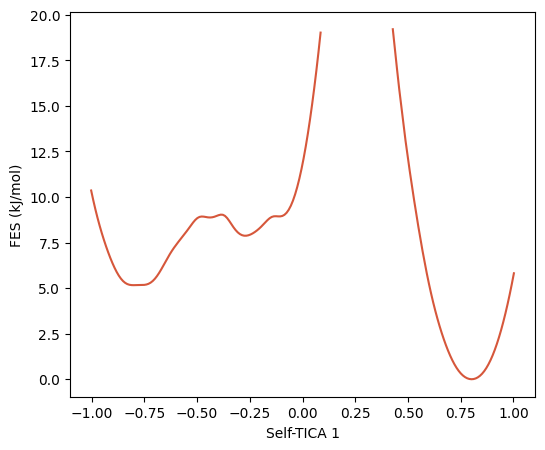

In [8]:
from mlcolvar.utils.fes import compute_fes

beta=1.
bias = df.filter(regex='opes.bias').values.sum(axis=1)
logweights = beta*bias
w = np.exp(logweights)

fig,ax = plt.subplots(1,1,figsize=(6,5),dpi=100)

# compute cvs
with torch.no_grad():
    model.eval()
    s = model(torch.Tensor(X)).numpy()

fes,grid,bounds,error = compute_fes(s,
                                    kbt=1,
                                    weights=w,
                                    blocks=1,
                                    bandwidth=0.02, scale_by='range',
                                    plot=True, plot_max_fes=20, ax = ax)

ax.set_xlabel('Self-TICA 1')
ax.set_ylabel('FES (kJ/mol)')

### Plot CVs isolines

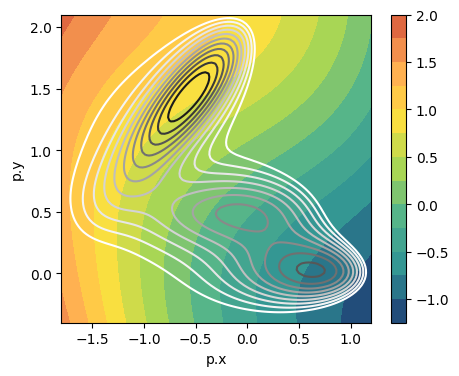

In [9]:
fig,axs = plt.subplots( 1, n_components, figsize=(5*n_components,4) )
if n_components == 1:
    axs = [axs]
for i in range(n_components):
    ax = axs[i]

    plot_isolines_2D(muller_brown_potential, levels=np.linspace(0,24,12),mode='contour',ax=ax)
    cs= plot_isolines_2D(model, component=i, ax=ax)
    cbar.set_label(f'TICA 1')
    ax.set_xlabel('p.x')
    ax.set_ylabel('p.y')

### Predict other lag-time

In [10]:
dataset = create_timelagged_dataset(X, lag_time=10,progress_bar=True)
datamodule = DictModule(dataset,lengths=[1], batch_size=5000, random_split=False, shuffle=False)
datamodule.setup()
model.compute_tica(datamodule, lag_time=10, update_optimal=True)

/home/kzhu-iit.local/data/mlcolvar-release-2.0/mlcolvar/data/datamodule.py:136: UserWarning: A torch.generator was provided but it is not used with random_split=False
  warnings.warn(


(array([0.94065199]),
 array([[ 0.48801262],
        [-0.19045136],
        [ 0.41322967],
        [ 0.65035989],
        [ 0.36310496]]))

Text(0, 0.5, 'FES (kJ/mol)')

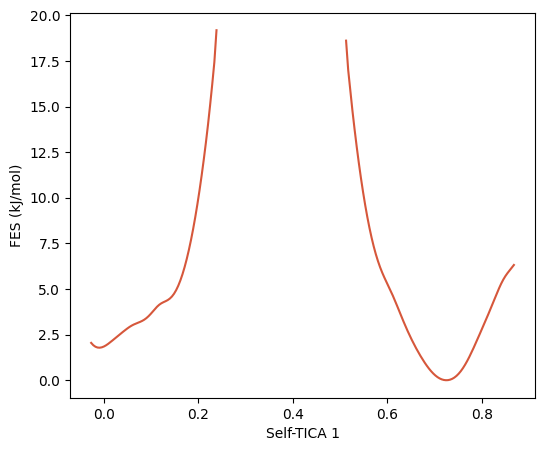

In [11]:
fig,ax = plt.subplots(1,1,figsize=(6,5),dpi=100)

# compute cvs
with torch.no_grad():
    model.eval()
    s = model(torch.Tensor(X)).numpy()

fes,grid,bounds,error = compute_fes(s,
                                    kbt=1,
                                    blocks=1,
                                    bandwidth=0.02, scale_by='range',
                                    plot=True, plot_max_fes=20, ax = ax)

ax.set_xlabel('Self-TICA 1')
ax.set_ylabel('FES (kJ/mol)')

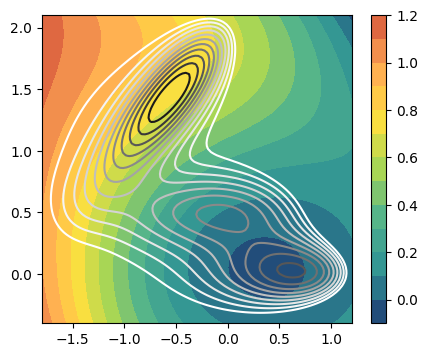

In [12]:
fig,axs = plt.subplots( 1, n_components, figsize=(5*n_components,4) )
if n_components == 1:
    axs = [axs]
for i in range(n_components):
    ax = axs[i]

    plot_isolines_2D(muller_brown_potential,levels=np.linspace(0,24,12),mode='contour',ax=ax)
    plot_isolines_2D(model, component=i, ax=ax)
    #ax.scatter(X[:,0],X[:,1],s=1, alpha=0.2,c='w')